# MAE ENCODER WITH VARIANCE BASED CLASSIFIER

# Imports

In [67]:
import sys
import shutil
from collections import Counter

import torch
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
import torch.nn as nn
from transformers import ViTMAEModel

import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc

import json
import os
import random
from tqdm.auto import tqdm



## Config

### Directories

In [126]:
# Check if running in Google Colab
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')

    # Configuration: Path to zip in Drive and extraction target
    # Assuming you uploaded Dataset.zip to AIgen_Image_Detection_Via_DL folder
    ZIP_SOURCE = "/content/drive/MyDrive/AIgen_Image_Detection_Via_DL/Dataset.zip"
    DATASET_ROOT = "/content/Dataset"

    if not os.path.exists(DATASET_ROOT):
        print("Copying zip from Drive to local runtime (faster unzipping)...")
        # Copy to local disk /content/ to avoid Drive I/O during unzip
        shutil.copy(ZIP_SOURCE, "/content/Dataset.zip")
        print("Unzipping dataset...")
        shutil.unpack_archive("/content/Dataset.zip", "/content")
        print("Done!")
    else:
        print("Dataset already extracted.")
else:
    DEFAULT_ROOT = "E:/pigeon/Documents/ENSF617/AIgen_Image_Detection_Via_DL/Dataset"
    DATASET_ROOT = os.getenv("DATASET_ROOT", DEFAULT_ROOT)

TRAIN_DIR = os.path.join(DATASET_ROOT, "train")
TEST_DIR = os.path.join(DATASET_ROOT, "test")
VAL_DIR = os.path.join(DATASET_ROOT, "val")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset already extracted.


### Hyperparameters

In [127]:
DATA_LOADER_BATCH_SIZE = 32
DATA_LOADER_NUM_WORKERS = 2

NUM_EPOCHS = 20
LEARNING_RATE = 1e-3

PATIENCE = 3

# Reproducibility
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

set_seed(42)

---

## Data Prepraration

### Data Preprocessing - Normalization

In [128]:
# Image size expected by ViT-MAE (as it was pretrained on 224x224)
IMG_SIZE = 224

# Normalization for ViT models
# standard ImageNet stats used by ViT/MAE
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

### Data Preprocessing - Augmentation (for training)

In [129]:
# adding data augmentation for training set
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

### Datasets & Data Loaders

In [130]:
# Datasets
train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transform)
val_dataset   = datasets.ImageFolder(root=VAL_DIR, transform=transform)
test_dataset  = datasets.ImageFolder(root=TEST_DIR, transform=transform)

In [131]:
# Dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=DATA_LOADER_BATCH_SIZE,
    shuffle=True, # only shuffle training data
    num_workers=DATA_LOADER_NUM_WORKERS,
    persistent_workers=True,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=DATA_LOADER_BATCH_SIZE,
    shuffle=False,
    num_workers=DATA_LOADER_NUM_WORKERS,
    persistent_workers=True,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=DATA_LOADER_BATCH_SIZE,
    shuffle=False,
    num_workers=DATA_LOADER_NUM_WORKERS,
    persistent_workers=True,
    pin_memory=True
)

# Class mapping check
print("Classes:", train_dataset.classes)
print("Class to idx:", train_dataset.class_to_idx)

Classes: ['Fake', 'Real']
Class to idx: {'Fake': 0, 'Real': 1}


## Dataset Size Check

In [132]:
def get_class_counts(dataset):
    # ImageFolder stores labels in dataset.targets
    return Counter(dataset.targets)

train_counts = get_class_counts(train_dataset)
val_counts   = get_class_counts(val_dataset)
test_counts  = get_class_counts(test_dataset)

def map_counts(counts, dataset):
    idx_to_class = {v: k for k, v in dataset.class_to_idx.items()}
    return {
        idx_to_class[i]: counts.get(i, 0)
        for i in range(len(idx_to_class))
    }
print("\nTrain total:", sum(train_counts.values()))
print("Validation total:", sum(val_counts.values()))
print("Test total:", sum(test_counts.values()))

print("\nTrain class counts:", map_counts(train_counts, train_dataset))
print("Validation class counts:", map_counts(val_counts, val_dataset))
print("Test class counts:", map_counts(test_counts, test_dataset))


Train total: 2500
Validation total: 1182
Test total: 1250

Train class counts: {'Fake': 1000, 'Real': 1500}
Validation class counts: {'Fake': 432, 'Real': 750}
Test class counts: {'Fake': 500, 'Real': 750}


## Checking Device

In [133]:
if torch.backends.mps.is_available():
    device = torch.device("mps")   # Apple GPU
    print("Using MPS (Apple GPU)")
elif torch.cuda.is_available():
    device = torch.device("cuda")  # NVIDIA GPU
    print("Using CUDA")
else:
    device = torch.device("cpu")   # fallback
    print("Using CPU")

Using CUDA


---

## Model Definition
- Uses pretrained MAE as its encoder
- Logistic Regression as its classifier

In [134]:
class MAEVarianceClassifier(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        # Load the pretrained ViT-MAE model as the encoder
        self.encoder = ViTMAEModel.from_pretrained("facebook/vit-mae-base")
        # Freeze the encoder parameters to prevent training
        for param in self.encoder.parameters():
            param.requires_grad = False

        self.hidden_dim = self.encoder.config.hidden_size  # = 768 = the feature dimension

        # layer norm + linear layer for classification (logistic regression)
        self.classifier = nn.Sequential(
            nn.LayerNorm(self.hidden_dim),
            nn.Linear(self.hidden_dim, num_classes)
        )

    def forward(self, pixel_values):
        outputs = self.encoder(pixel_values=pixel_values)

        patch_embeddings = outputs.last_hidden_state[:, 1:, :]  # remove CLS, keep only patch embeddings
        # compute variance across patch embeddings for each sample in the batch
        # measures how much each feature dimesion varies spatially
        var_vector = patch_embeddings.var(dim=1)

        # Feed the variance vector into the classifier
        logits = self.classifier(var_vector)
        return logits

### Model Initialization

In [135]:
model = MAEVarianceClassifier(num_classes=2) # Binary classification for now
model = model.to(device)

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTMAEModel LOAD REPORT from: facebook/vit-mae-base
Key                                                                              | Status     |  | 
---------------------------------------------------------------------------------+------------+--+-
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.attention.output.dense.weight    | UNEXPECTED |  | 
decoder.decoder_pred.bias                                                        | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.intermediate.dense.bias          | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.output.dense.bias                | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.layernorm_after.weight           | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.layernorm_before.bias            | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.layernorm_after.bias             | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.

#### Verify encoder is frozen

In [136]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print(f"Trainable params: {trainable_params}")
print(f"Total params: {total_params}")

Trainable params: 3074
Total params: 85801730


---
## Training

### Loss + Optimizer
- Only pass **classifier parameters** to optimizer since we do not want to train the encoder.
- This avoids accidentally trying to update the frozen encoder.

In [137]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.classifier.parameters(),
    lr=LEARNING_RATE
)

## Training Function

In [138]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    # tqdm for progress tracking
    for images, labels in tqdm(dataloader, desc="Training", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    acc = correct / total

    return avg_loss, acc

## Evaluation Function

In [140]:
def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / len(dataloader), correct / total

---

## Main Training Loop

In [141]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}


best_val_loss = float("inf")
counter = 0

# Ensure encoder stays deterministic
model.encoder.eval()

# training loop with early stopping
for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, device
    )

    val_loss, val_acc = evaluate(
        model, val_loader, criterion, device
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}: "
          f"Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, "
          f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

    # ---- Early Stopping ----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0

        # Save best model
        torch.save(model.state_dict(), "best_variance_based_model.pt")
    else:
        counter += 1

        if counter >= PATIENCE:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break



Training:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 1: Train Loss=0.6580, Train Acc=0.6176, Val Loss=0.6386, Val Acc=0.6565


Training:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 2: Train Loss=0.6345, Train Acc=0.6456, Val Loss=0.5999, Val Acc=0.6963


Training:   0%|          | 0/79 [00:00<?, ?it/s]

...

Epoch 18: Train Loss=0.5260, Train Acc=0.7432, Val Loss=0.4837, Val Acc=0.7766


Training:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 19: Train Loss=0.5319, Train Acc=0.7360, Val Loss=0.4859, Val Acc=0.7758


Training:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 20: Train Loss=0.5384, Train Acc=0.7328, Val Loss=0.4856, Val Acc=0.7766


### Plot training/validation curves
- Loss and Accuracy

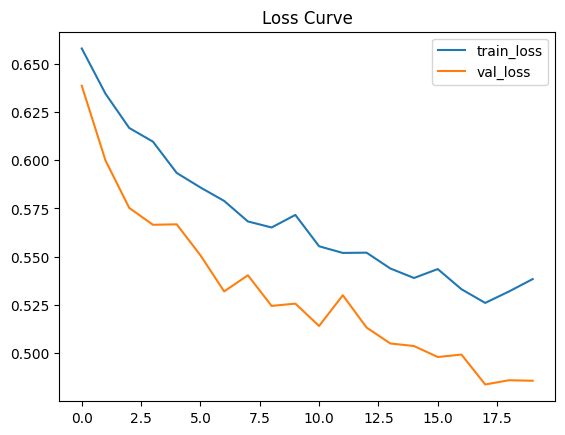

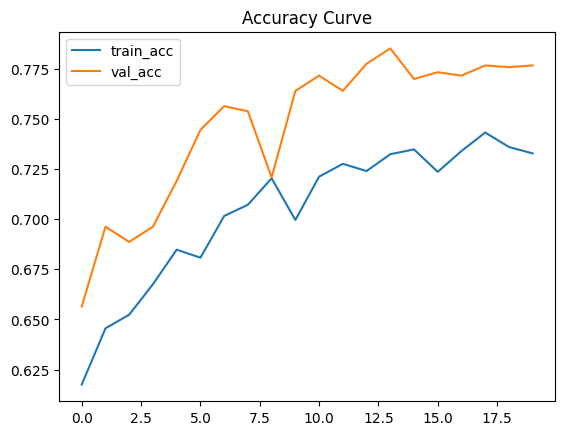

In [142]:
# Loss
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.legend()
plt.title("Loss Curve")
plt.savefig("loss_curve.png")
plt.show()

# Accuracy
plt.plot(history["train_acc"], label="train_acc")
plt.plot(history["val_acc"], label="val_acc")
plt.legend()
plt.title("Accuracy Curve")
plt.savefig("accuracy_curve.png")
plt.show()

## Testing

In [143]:
# load best model
model.load_state_dict(torch.load("best_variance_based_model.pt"))
model.eval()

# evaluate on test set
y_true = []
y_pred = []
y_prob = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)[:, 0]  # Fake probability
        preds = (probs > 0.5).long()  # 1 = Fake, 0 = Real (Fake as the possitive class)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

y_true_bin = (y_true == 0).astype(int) # treat fake as the possitive class


### Compute Metrics

In [144]:
metrics = {
    "accuracy": accuracy_score(y_true_bin, y_pred),
    "precision": precision_score(y_true_bin, y_pred),
    "recall": recall_score(y_true_bin, y_pred),
    "f1_score": f1_score(y_true_bin, y_pred),
    "roc_auc": roc_auc_score(y_true_bin, y_prob)
}

print(metrics)

{'accuracy': 0.7584, 'precision': 0.7877906976744186, 'recall': 0.542, 'f1_score': 0.6421800947867299, 'roc_auc': np.float64(0.8306373333333333)}


### Save Metrics

In [145]:
with open("variance_based_test_metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

## ROC Curve & Confusion Matrix

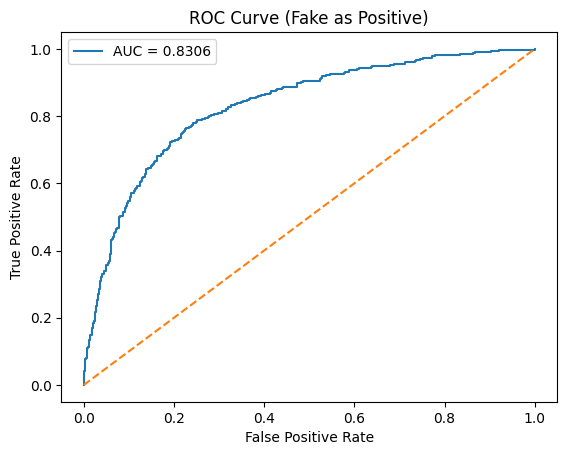

In [146]:
fpr, tpr, _ = roc_curve(y_true_bin, y_prob)  # Fake = positive
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Fake as Positive)")
plt.legend()
plt.savefig("roc_curve.png")
plt.show()

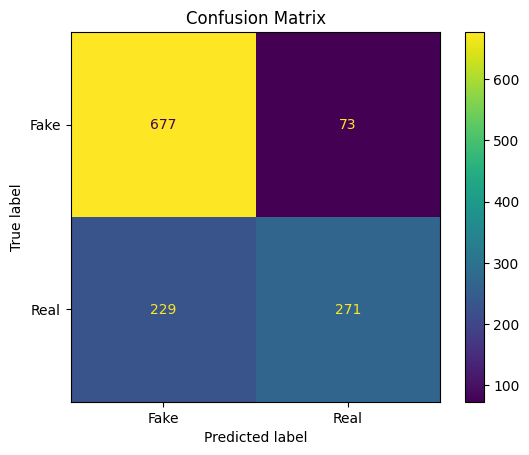

In [147]:
cm = confusion_matrix(y_true_bin, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fake", "Real"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png")
plt.show()

## Patch Variance Inspection

In [109]:
def extract_patch_variance_distribution(model, dataloader, device):
    model.eval()

    fake_vars = []
    real_vars = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)

            patches = model.encoder(images).last_hidden_state  # (B, N, D)

            # variance across patches → (B, D)
            var = patches.var(dim=1)

            # collapse feature dimension → one scalar per image
            var = var.mean(dim=1)

            var = var.cpu().numpy()
            labels = labels.numpy()

            for v, y in zip(var, labels):
                if y == 0:  # Fake
                    fake_vars.append(v)
                else:
                    real_vars.append(v)

    return fake_vars, real_vars


In [110]:
# get per-image patch variance
fake_vars_all = []
real_vars_all = []

for loader in [train_loader, val_loader, test_loader]:
    fake_v, real_v = extract_patch_variance_distribution(model, loader, device)
    fake_vars_all.extend(fake_v)
    real_vars_all.extend(real_v)

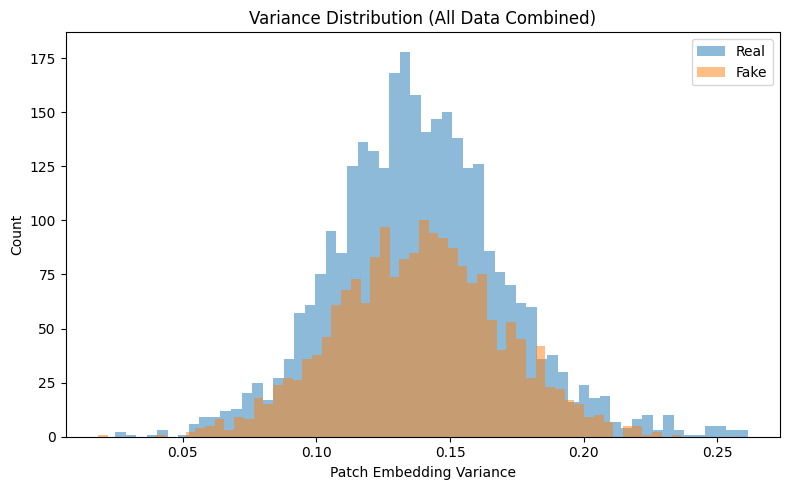

In [112]:
plt.figure(figsize=(8, 5))

plt.hist(real_vars_all, bins=60, alpha=0.5, label="Real")
plt.hist(fake_vars_all, bins=60, alpha=0.5, label="Fake")

plt.xlabel("Patch Embedding Variance")
plt.ylabel("Count")
plt.title("Variance Distribution (All Data Combined)")
plt.legend()

plt.tight_layout()
plt.savefig("variance_distribution.png")
plt.show()